# CSE445 Machine Learning Project
## Animal Image Classification — Logistic Regression (Faiyazul Islam)

Run **all cells in order**. The first cells extract VGG16 features; the last cell is your classifier.

Set `BASE_DIR` in the data cell to your local `data` folder (`train` / `val` / `test` with class subfolders).

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve

print("Imports OK")

Imports OK


In [2]:
# Point this at the folder that contains train/, val/, test/
BASE_DIR = Path(r"C:\Users\skull\OneDrive\Desktop\Project\CSE445-Project-main\data")

# Uncomment if your dataset is somewhere else:
# BASE_DIR = Path(r"F:\CSE445 Project\data")
# BASE_DIR = Path(r"C:\Users\skull\Downloads\CSE445-Project\data")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {BASE_DIR}\n"
        "Copy train/ val/ test/ into that path, or change BASE_DIR above."
    )

def load_data(folder_name):
    dir_path = str(BASE_DIR / folder_name)
    return image_dataset_from_directory(
        dir_path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

print(f"Loading datasets from {BASE_DIR} ...")
train_ds = load_data("train")
val_ds = load_data("val")
test_ds = load_data("test")

y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_val = np.concatenate([y for x, y in val_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)

class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Loading datasets from C:\Users\skull\OneDrive\Desktop\Project\CSE445-Project-main\data ...
Found 350 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Classes found: ['cat', 'cow', 'dog', 'lamb', 'zebra']


In [3]:
vgg_feature_extractor = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    pooling="avg",
)

def extract_features(dataset):
    features = []
    for images, labels in dataset:
        preprocessed_images = preprocess_input(images)
        extracted = vgg_feature_extractor.predict(preprocessed_images, verbose=0)
        features.append(extracted)
    return np.vstack(features)

print("Extracting features from Train set...")
X_train = extract_features(train_ds)

print("Extracting features from Test set...")
X_test = extract_features(test_ds)

print(f"Feature extraction complete! Training features shape: {X_train.shape}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Extracting features from Train set...
Extracting features from Test set...
Feature extraction complete! Training features shape: (350, 512)


---
### Member 1: FAIYAZUL ISLAM
**Classifier:** Logistic Regression

Training Logistic Regression...
Logistic Regression finished. Test Accuracy: 97.33%

--- Classification Report ---
              precision    recall  f1-score   support

         cat       1.00      1.00      1.00        15
         cow       0.88      1.00      0.94        15
         dog       1.00      1.00      1.00        15
        lamb       1.00      0.87      0.93        15
       zebra       1.00      1.00      1.00        15

    accuracy                           0.97        75
   macro avg       0.98      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



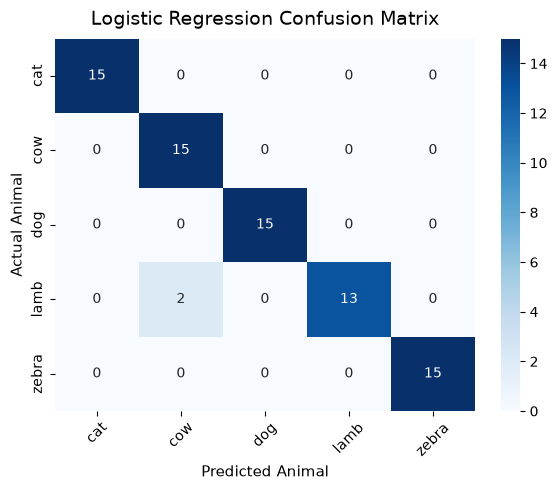

Calculating Learning Curve...


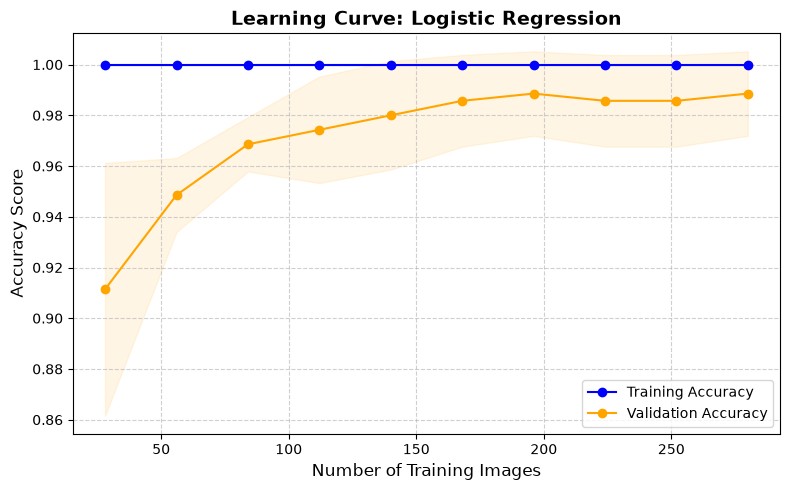

In [4]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression finished. Test Accuracy: {acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Logistic Regression Confusion Matrix", fontsize=14, pad=10)
plt.ylabel("Actual Animal", fontsize=11)
plt.xlabel("Predicted Animal", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Calculating Learning Curve...")
np.random.seed(42)
shuffle_indices = np.random.permutation(len(X_train))
X_train_shuffled = X_train[shuffle_indices]
y_train_shuffled = y_train[shuffle_indices]

train_sizes, train_scores, test_scores = learning_curve(
    lr_model,
    X_train_shuffled,
    y_train_shuffled,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training Accuracy")
plt.plot(train_sizes, test_mean, "o-", color="orange", label="Validation Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
plt.title("Learning Curve: Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Number of Training Images", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()